# Analise Exploratoria - Deteccao de Anomalias em Campanhas de E-mail Marketing

Visualiza series temporais de `taxa_abertura` e `ctr` para campanhas de exemplo,
sobrepondo tres fontes de sinal:

- **Anomalia real injetada** (gabarito) — o que de fato foi simulado
- **Deteccao via z-score** (por campanha, ver `detect_anomalies_zscore.py`)
- **Deteccao via Isolation Forest** (por campanha, ver `detect_anomalies_ml.py`)

O objetivo e evidenciar visualmente onde os metodos acertam, erram e onde ha
sobreposicao entre eles.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / "data" / "processed"
RAW_DIR = BASE_DIR / "data" / "raw"
OUTPUTS_DIR = BASE_DIR / "outputs"

sys.path.insert(0, str(BASE_DIR / "src"))
import visualization as viz

viz.aplicar_estilo_padrao()

In [2]:
agregado = pd.read_csv(PROCESSED_DIR / "fato_agregado_diario.csv", parse_dates=["dat_referencia"])
gabarito = pd.read_csv(RAW_DIR / "gabarito_anomalias.csv")
zscore = pd.read_csv(OUTPUTS_DIR / "anomalias_zscore.csv", parse_dates=["dat_referencia"])
isolation_forest = pd.read_csv(OUTPUTS_DIR / "anomalias_isolation_forest.csv", parse_dates=["dat_referencia"])

print(f"{len(agregado)} disparos agregados, {len(gabarito)} disparos no gabarito.")
print(f"{len(zscore)} linhas de deteccao zscore, {len(isolation_forest)} linhas de deteccao isolation_forest.")

625 disparos agregados, 625 disparos no gabarito.
1875 linhas de deteccao zscore, 625 linhas de deteccao isolation_forest.


## Selecionando campanhas de exemplo

Escolhemos as campanhas com maior diversidade de tipos de anomalia injetada no
gabarito (`queda_deliverability`, `clique_bot`, `pico_engajamento`), para
ilustrar os tres cenarios no menor numero de exemplos possivel.

In [3]:
campanhas_exemplo = viz.selecionar_campanhas_exemplo(gabarito, n=4)
print("Campanhas de exemplo selecionadas:", campanhas_exemplo)

Campanhas de exemplo selecionadas: [1, 3, 10, 27]


## Graficos por campanha

A funcao plotar_campanha (src/visualization.py, reutilizada pelo app
Streamlit) plota, para cada campanha, dois paineis empilhados (`taxa_abertura` e `ctr`) ao longo
dos disparos (`id_disparo`). Marcadores sobrepostos a linha indicam:

- **X vermelho**: anomalia real (gabarito)
- **Triangulo violeta (contorno)**: deteccao z-score
- **Quadrado laranja (contorno)**: deteccao Isolation Forest

Quando os tres simbolos coincidem no mesmo disparo, houve acerto (verdadeiro
positivo). Um X vermelho sem nenhum marcador de metodo ao redor e um falso
negativo; um marcador de metodo sem X vermelho correspondente e um falso
positivo — atencao especial aos disparos de `pico_engajamento`, que sao
anomalias estatisticas "boas" e idealmente nao deveriam ser marcadas como
problema (ver `evaluate.py`).

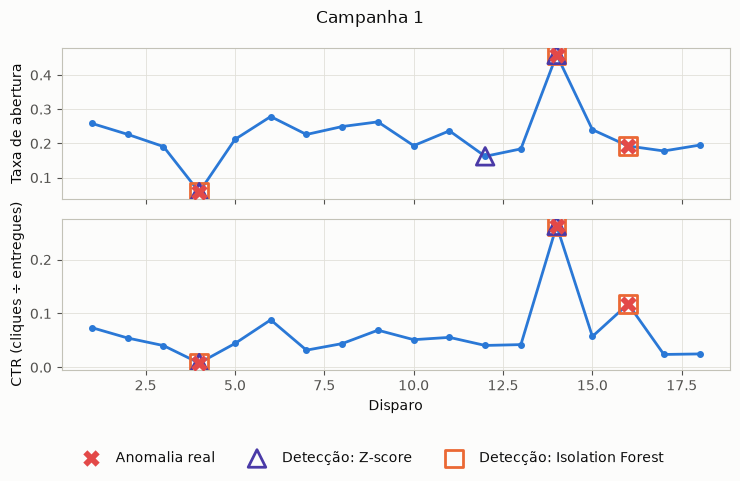

#### O que os detectores encontraram
- 🔎 Disparo 4: taxa de abertura em 5.8%, 5.0 desvios-padrão fora do histórico recente da campanha — **Z-score** marcou como anomalia.
- 🔎 Disparo 4: ctr (cliques ÷ entregues) em 0.8%, 2.9 desvios-padrão fora do histórico recente da campanha — **Z-score** marcou como anomalia.
- 🔎 Disparo 4: ctor em 13.6%, 2.9 desvios-padrão fora do histórico recente da campanha — **Z-score** marcou como anomalia.
- 🔎 Disparo 12: taxa de abertura em 16.2%, 2.6 desvios-padrão fora do histórico recente da campanha — **Z-score** marcou como anomalia.
- 🔎 Disparo 14: taxa de abertura em 45.9%, 6.0 desvios-padrão fora do histórico recente da campanha — **Z-score** marcou como anomalia.
- 🔎 Disparo 14: ctr (cliques ÷ entregues) em 26.3%, 19.8 desvios-padrão fora do histórico recente da campanha — **Z-score** marcou como anomalia.
- 🔎 Disparo 14: ctor em 57.2%, 10.3 desvios-padrão fora do histórico recente da campanha — **Z-score** marcou como anomalia.
- 🔎 Disparo 4: combinação de taxa de abertura (5.8%) e CTR (0.8%) destoante das demais da campanha — **Isolation Forest** marcou como anomalia.
- 🔎 Disparo 14: combinação de taxa de abertura (45.9%) e CTR (26.3%) destoante das demais da campanha — **Isolation Forest** marcou como anomalia.
- 🔎 Disparo 16: combinação de taxa de abertura (19.3%) e CTR (11.8%) destoante das demais da campanha — **Isolation Forest** marcou como anomalia.

#### O que de fato aconteceu (gabarito)
- ⚠️ Disparo 4 — queda de entregabilidade: detectada por **ambos os métodos**.
- 📈 Disparo 14 — pico de engajamento (bom): detectada por **ambos os métodos**.
- ⚠️ Disparo 16 — clique suspeito (possível bot): detectada só pelo **Isolation Forest**.

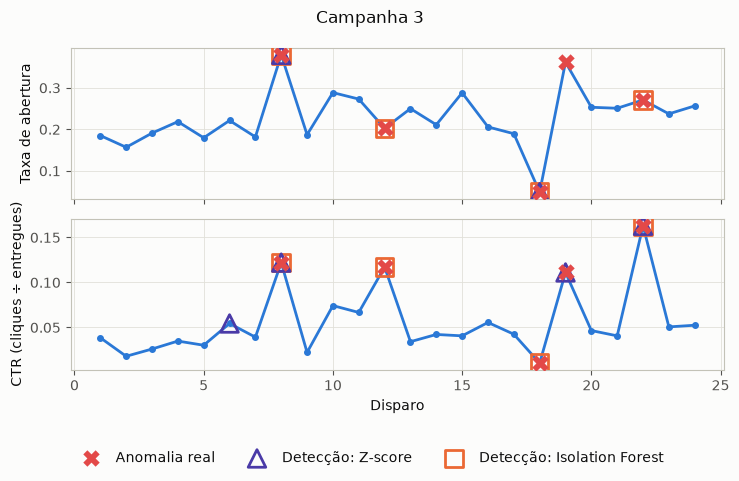

#### O que os detectores encontraram
- 🔎 Disparo 6: ctr (cliques ÷ entregues) em 5.4%, 3.1 desvios-padrão fora do histórico recente da campanha — **Z-score** marcou como anomalia.
- 🔎 Disparo 6: ctor em 24.6%, 2.5 desvios-padrão fora do histórico recente da campanha — **Z-score** marcou como anomalia.
- 🔎 Disparo 8: ctr (cliques ÷ entregues) em 12.2%, 7.1 desvios-padrão fora do histórico recente da campanha — **Z-score** marcou como anomalia.
- 🔎 Disparo 8: taxa de abertura em 38.0%, 7.6 desvios-padrão fora do histórico recente da campanha — **Z-score** marcou como anomalia.
- 🔎 Disparo 8: ctor em 32.1%, 3.0 desvios-padrão fora do histórico recente da campanha — **Z-score** marcou como anomalia.
- 🔎 Disparo 12: ctor em 57.8%, 5.2 desvios-padrão fora do histórico recente da campanha — **Z-score** marcou como anomalia.
- 🔎 Disparo 18: taxa de abertura em 4.9%, 4.7 desvios-padrão fora do histórico recente da campanha — **Z-score** marcou como anomalia.
- 🔎 Disparo 19: ctr (cliques ÷ entregues) em 11.1%, 4.9 desvios-padrão fora do histórico recente da campanha — **Z-score** marcou como anomalia.
- 🔎 Disparo 22: ctr (cliques ÷ entregues) em 16.3%, 3.4 desvios-padrão fora do histórico recente da campanha — **Z-score** marcou como anomalia.
- 🔎 Disparo 22: ctor em 60.2%, 7.0 desvios-padrão fora do histórico recente da campanha — **Z-score** marcou como anomalia.
- 🔎 Disparo 8: combinação de taxa de abertura (38.0%) e CTR (12.2%) destoante das demais da campanha — **Isolation Forest** marcou como anomalia.
- 🔎 Disparo 12: combinação de taxa de abertura (20.3%) e CTR (11.7%) destoante das demais da campanha — **Isolation Forest** marcou como anomalia.
- 🔎 Disparo 18: combinação de taxa de abertura (4.9%) e CTR (1.0%) destoante das demais da campanha — **Isolation Forest** marcou como anomalia.
- 🔎 Disparo 22: combinação de taxa de abertura (27.1%) e CTR (16.3%) destoante das demais da campanha — **Isolation Forest** marcou como anomalia.

#### O que de fato aconteceu (gabarito)
- 📈 Disparo 8 — pico de engajamento (bom): detectada por **ambos os métodos**.
- ⚠️ Disparo 12 — clique suspeito (possível bot): detectada por **ambos os métodos**.
- ⚠️ Disparo 18 — queda de entregabilidade: detectada por **ambos os métodos**.
- 📈 Disparo 19 — pico de engajamento (bom): detectada só pelo **Z-score**.
- ⚠️ Disparo 22 — clique suspeito (possível bot): detectada por **ambos os métodos**.

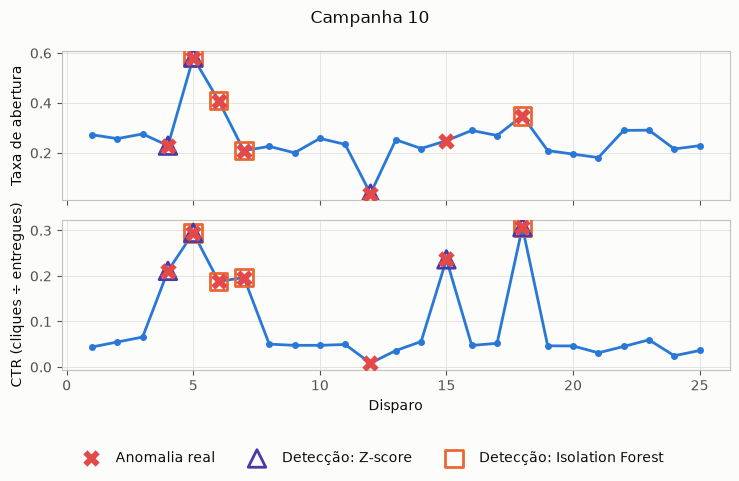

#### O que os detectores encontraram
- 🔎 Disparo 4: taxa de abertura em 22.9%, 3.9 desvios-padrão fora do histórico recente da campanha — **Z-score** marcou como anomalia.
- 🔎 Disparo 4: ctr (cliques ÷ entregues) em 21.1%, 14.3 desvios-padrão fora do histórico recente da campanha — **Z-score** marcou como anomalia.
- 🔎 Disparo 4: ctor em 92.2%, 18.2 desvios-padrão fora do histórico recente da campanha — **Z-score** marcou como anomalia.
- 🔎 Disparo 5: taxa de abertura em 58.2%, 15.1 desvios-padrão fora do histórico recente da campanha — **Z-score** marcou como anomalia.
- 🔎 Disparo 5: ctr (cliques ÷ entregues) em 29.5%, 2.6 desvios-padrão fora do histórico recente da campanha — **Z-score** marcou como anomalia.
- 🔎 Disparo 12: taxa de abertura em 3.7%, 2.8 desvios-padrão fora do histórico recente da campanha — **Z-score** marcou como anomalia.
- 🔎 Disparo 15: ctr (cliques ÷ entregues) em 23.6%, 11.4 desvios-padrão fora do histórico recente da campanha — **Z-score** marcou como anomalia.
- 🔎 Disparo 15: ctor em 95.0%, 17.9 desvios-padrão fora do histórico recente da campanha — **Z-score** marcou como anomalia.
- 🔎 Disparo 18: ctr (cliques ÷ entregues) em 30.7%, 2.9 desvios-padrão fora do histórico recente da campanha — **Z-score** marcou como anomalia.
- 🔎 Disparo 5: combinação de taxa de abertura (58.2%) e CTR (29.5%) destoante das demais da campanha — **Isolation Forest** marcou como anomalia.
- 🔎 Disparo 6: combinação de taxa de abertura (40.9%) e CTR (18.8%) destoante das demais da campanha — **Isolation Forest** marcou como anomalia.
- 🔎 Disparo 7: combinação de taxa de abertura (20.9%) e CTR (19.7%) destoante das demais da campanha — **Isolation Forest** marcou como anomalia.
- 🔎 Disparo 18: combinação de taxa de abertura (34.9%) e CTR (30.7%) destoante das demais da campanha — **Isolation Forest** marcou como anomalia.

#### O que de fato aconteceu (gabarito)
- ⚠️ Disparo 4 — clique suspeito (possível bot): detectada só pelo **Z-score**.
- 📈 Disparo 5 — pico de engajamento (bom): detectada por **ambos os métodos**.
- 📈 Disparo 6 — pico de engajamento (bom): detectada só pelo **Isolation Forest**.
- ⚠️ Disparo 7 — clique suspeito (possível bot): detectada só pelo **Isolation Forest**.
- ⚠️ Disparo 12 — queda de entregabilidade: detectada só pelo **Z-score**.
- ⚠️ Disparo 15 — clique suspeito (possível bot): detectada só pelo **Z-score**.
- ⚠️ Disparo 18 — clique suspeito (possível bot): detectada por **ambos os métodos**.

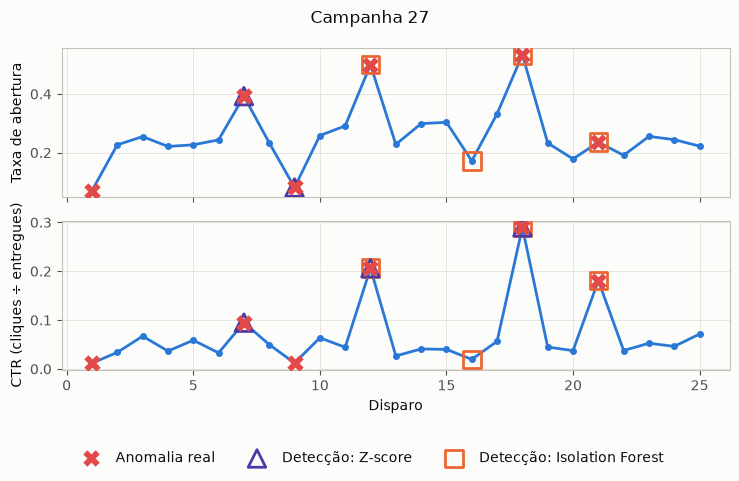

#### O que os detectores encontraram
- 🔎 Disparo 7: taxa de abertura em 39.3%, 2.7 desvios-padrão fora do histórico recente da campanha — **Z-score** marcou como anomalia.
- 🔎 Disparo 7: ctr (cliques ÷ entregues) em 9.5%, 2.7 desvios-padrão fora do histórico recente da campanha — **Z-score** marcou como anomalia.
- 🔎 Disparo 9: taxa de abertura em 8.1%, 2.8 desvios-padrão fora do histórico recente da campanha — **Z-score** marcou como anomalia.
- 🔎 Disparo 12: ctr (cliques ÷ entregues) em 20.6%, 5.6 desvios-padrão fora do histórico recente da campanha — **Z-score** marcou como anomalia.
- 🔎 Disparo 12: ctor em 41.2%, 4.4 desvios-padrão fora do histórico recente da campanha — **Z-score** marcou como anomalia.
- 🔎 Disparo 18: ctr (cliques ÷ entregues) em 29.0%, 3.2 desvios-padrão fora do histórico recente da campanha — **Z-score** marcou como anomalia.
- 🔎 Disparo 18: ctor em 54.2%, 3.1 desvios-padrão fora do histórico recente da campanha — **Z-score** marcou como anomalia.
- 🔎 Disparo 21: ctor em 76.7%, 3.4 desvios-padrão fora do histórico recente da campanha — **Z-score** marcou como anomalia.
- 🔎 Disparo 12: combinação de taxa de abertura (50.0%) e CTR (20.6%) destoante das demais da campanha — **Isolation Forest** marcou como anomalia.
- 🔎 Disparo 16: combinação de taxa de abertura (17.2%) e CTR (2.0%) destoante das demais da campanha — **Isolation Forest** marcou como anomalia.
- 🔎 Disparo 18: combinação de taxa de abertura (53.4%) e CTR (29.0%) destoante das demais da campanha — **Isolation Forest** marcou como anomalia.
- 🔎 Disparo 21: combinação de taxa de abertura (23.6%) e CTR (18.1%) destoante das demais da campanha — **Isolation Forest** marcou como anomalia.

#### O que de fato aconteceu (gabarito)
- ⚠️ Disparo 1 — queda de entregabilidade: **não detectada** por nenhum método.
- 📈 Disparo 7 — pico de engajamento (bom): detectada só pelo **Z-score**.
- ⚠️ Disparo 9 — queda de entregabilidade: detectada só pelo **Z-score**.
- 📈 Disparo 12 — pico de engajamento (bom): detectada por **ambos os métodos**.
- 📈 Disparo 18 — pico de engajamento (bom): detectada por **ambos os métodos**.
- ⚠️ Disparo 21 — clique suspeito (possível bot): detectada por **ambos os métodos**.

In [4]:
for id_campanha in campanhas_exemplo:
    fig = viz.plotar_campanha(id_campanha, agregado, gabarito, zscore, isolation_forest)
    plt.show()

    insight = viz.gerar_insight_campanha(
        id_campanha, agregado, zscore, isolation_forest, gabarito=gabarito
    )
    display(Markdown(insight))

## Observacoes

- Nas campanhas selecionadas, os disparos de `queda_deliverability` aparecem
  como um vale isolado em `taxa_abertura`, geralmente capturado por ambos os
  metodos.
- Os disparos de `clique_bot` sobem em `ctr` sem uma subida equivalente em
  `taxa_abertura` no mesmo disparo — e o padrao que o Isolation Forest, por
  ser multivariado, tende a capturar melhor que o z-score (ver
  `outputs/comparativo_metodos.csv`).
- Os disparos de `pico_engajamento` sobem em ambas as metricas ao mesmo
  tempo. Repare que, quando marcados por algum metodo, isso e um falso
  alarme esperado no cenario atual — nenhum dos dois detectores usa a
  direcao do desvio, entao um pico bom pode ser confundido com anomalia.